In [15]:
import librosa 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from scipy.io.wavfile import read
from IPython.display import Audio
from scipy.signal import find_peaks

In [43]:
def improved_onset_detector(x, sr, hop_length=512, frame_length=1024, threshold=0.15):
    
    rmse = librosa.feature.rms(
        y=x,
        frame_length=frame_length,
        hop_length=hop_length,
        center=True)[0]

    rmse_diff = np.diff(rmse)
    novelty = np.concatenate([rmse_diff, [0]])  # pad to == rmse length

    novelty[novelty < 0] = 0 #only keep positive changes

    if novelty.max() > 0:
        novelty = novelty / novelty.max() #normalize to [0, 1]

    t = librosa.frames_to_time(np.arange(len(novelty)), sr=sr, hop_length=hop_length)

    peak_indices = []
    # local maxima detection with thresholding
    for i in range(1, len(novelty) - 1):
        if novelty[i] > threshold:
            if novelty[i] > novelty[i - 1] and novelty[i] > novelty[i + 1]:
                peak_indices.append(i)

    peak_indices = np.array(peak_indices)
    onset_times = t[peak_indices]

    plt.figure(figsize=(12, 4))
    plt.plot(t, novelty)
    for o in onset_times:
        plt.axvline(o, color='red', alpha=0.4)
    plt.xlabel("Time (s)")
    plt.title("Improved Onset Detection")
    plt.show()

    return onset_times, novelty, t


Compare with baseline

In [37]:
def baseline_onset_detector(x, sr, hop_length=512, peak_height=0.3): 
    #Compute onset strength envelope 
    onset_env = librosa.onset.onset_strength(y=x, sr=sr, hop_length=hop_length) 

    # 2. Normalize 
    onset_env = onset_env / np.max(onset_env) 

    # 3. Peak picking 
    peaks, _ = find_peaks( 
        onset_env, 
        height=peak_height, 
        distance=2 
    ) 

    # 4. Convert frames to time 
    onset_times = librosa.frames_to_time( 
        peaks, 
        sr=sr, 
        hop_length=hop_length 
    ) 

    t = librosa.frames_to_time(np.arange(len(onset_env)), sr=sr, hop_length=512) 

    plt.figure(figsize=(12, 4)) 
    plt.plot(t, onset_env, label="Onset Strength") 
    for o in onset_times: 
        plt.axvline(o, color='red', alpha=0.4) 
    plt.xlabel("Time (s)") 
    plt.title("Baseline Onset Detection") 
    plt.legend() 
    plt.show() 

    return onset_times, onset_env 

 

Test

In [38]:
file_path = "/Users/shirinsathe/Downloads/AudioTechII/Projects/Project2/Data Set Cleaning/Ballroom/BallroomData/ChaChaCha/Albums-Cafe_Paradiso-05.wav"
x, sr = librosa.load(file_path, sr=22050, mono=True)

beats_df = pd.read_csv("/Users/shirinsathe/Downloads/AudioTechII/Projects/Project2/Data Set Cleaning/Ballroom CSVs/beat_csv/Albums-Cafe_Paradiso-05_beats.csv")
click_times = beats_df["beat_time"].values

print("Ground truth beats:", len(click_times))

Ground truth beats: 63


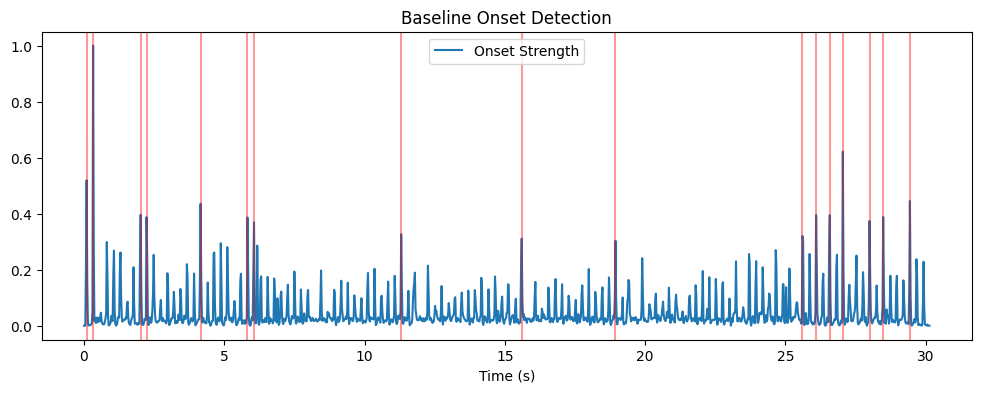

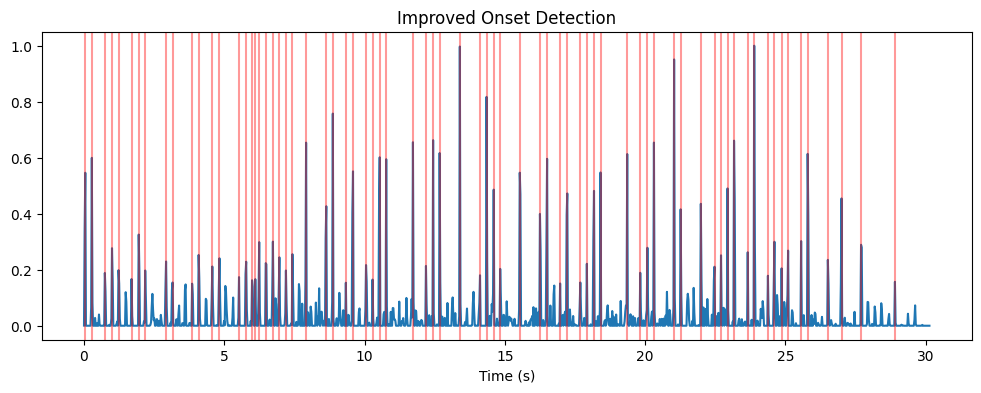

Old clicks: 17
Improved onsets: 74
First few times: [0.04643991 0.27863946 0.74303855 0.99845805 1.2306576 ]


In [44]:
onset_times, onset_env = baseline_onset_detector(x, sr) 
onset_times_imp, novelty, t = improved_onset_detector(x, sr)

print("Old clicks:", len(onset_times))
print("Improved onsets:", len(onset_times_imp))
print("First few times:", onset_times_imp[:5])

Evaluate using precision and recall.

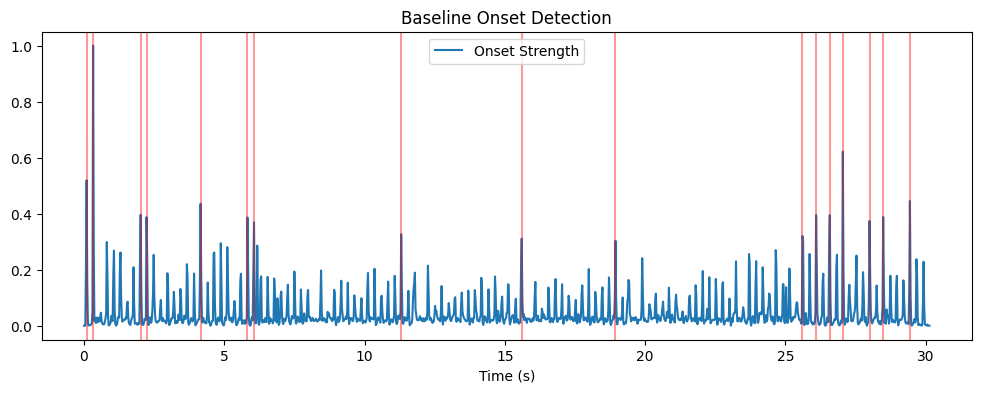

Baseline — Precision: 0.82  Recall: 0.22  F: 0.35
Improved — Precision: 0.55  Recall: 0.65  F: 0.60


In [ ]:
def evaluate_onsets(predicted, ground_truth, tolerance=0.05):
    matches, used = 0, set()
    for p in predicted:
        for i, gt in enumerate(ground_truth):
            if i not in used and abs(p - gt) <= tolerance:
                matches += 1
                used.add(i)
                break
    precision = matches / len(predicted) if len(predicted) > 0 else 0
    recall = matches / len(ground_truth) if len(ground_truth) > 0 else 0
    f = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0
    return precision, recall, f

onset_times_base, _ = baseline_onset_detector(x, sr)

p_b, r_b, f_b = evaluate_onsets(onset_times_base, click_times)
p_i, r_i, f_i = evaluate_onsets(onset_times_imp,  click_times)

print(f"Baseline — Precision: {p_b:.2f}  Recall: {r_b:.2f}  F: {f_b:.2f}")
print(f"Improved — Precision: {p_i:.2f}  Recall: {r_i:.2f}  F: {f_i:.2f}")

Getting worse precision, but better recall and F.